# 04 - Interpretability

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
TARGET_COL = "DEATH_EVENT"

current_dir = Path.cwd()
project_root = current_dir.parent if current_dir.name == "notebooks" else current_dir

tables_dir = project_root / "results" / "tables"
figures_dir = project_root / "results" / "figures"

for folder in [tables_dir, figures_dir]:
    folder.mkdir(parents=True, exist_ok=True)


def load_table(file_name):
    return pd.read_csv(tables_dir / file_name)

In [2]:
X_train_lr_with_time = load_table("X_train_lr_with_time.csv")
X_train_lr_without_time = load_table("X_train_lr_without_time.csv")

X_train_rf_with_time = load_table("X_train_rf_with_time.csv")
X_train_rf_without_time = load_table("X_train_rf_without_time.csv")

X_train_tree_with_time = load_table("X_train_tree_with_time.csv")
X_train_tree_without_time = load_table("X_train_tree_without_time.csv")

X_train_gb_with_time = load_table("X_train_gb_with_time.csv")
X_train_gb_without_time = load_table("X_train_gb_without_time.csv")

y_train = load_table("y_train.csv")[TARGET_COL]

In [3]:
logistic_with_time = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
logistic_without_time = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)

random_forest_with_time = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)
random_forest_without_time = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE)

decision_tree_with_time = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=4)
decision_tree_without_time = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced", max_depth=4)

gradient_boosting_with_time = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.05, max_depth=3)
gradient_boosting_without_time = GradientBoostingClassifier(random_state=RANDOM_STATE, n_estimators=100, learning_rate=0.05, max_depth=3)

logistic_with_time.fit(X_train_lr_with_time, y_train)
logistic_without_time.fit(X_train_lr_without_time, y_train)
random_forest_with_time.fit(X_train_rf_with_time, y_train)
random_forest_without_time.fit(X_train_rf_without_time, y_train)
decision_tree_with_time.fit(X_train_tree_with_time, y_train)
decision_tree_without_time.fit(X_train_tree_without_time, y_train)
gradient_boosting_with_time.fit(X_train_gb_with_time, y_train)
gradient_boosting_without_time.fit(X_train_gb_without_time, y_train)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.05
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [4]:
def logistic_coefficients(model, feature_names, time_version):
    table = pd.DataFrame({
        "feature": feature_names,
        "coefficient": model.coef_.ravel(),
    })
    table["absolute_coefficient"] = table["coefficient"].abs()
    table["time_version"] = time_version
    return table.sort_values("absolute_coefficient", ascending=False).reset_index(drop=True)

coef_with_time = logistic_coefficients(logistic_with_time, X_train_lr_with_time.columns, "with_time")
coef_without_time = logistic_coefficients(logistic_without_time, X_train_lr_without_time.columns, "without_time")

coef_with_time.to_csv(tables_dir / "logistic_coefficients_with_time.csv", index=False)
coef_without_time.to_csv(tables_dir / "logistic_coefficients_without_time.csv", index=False)

coef_with_time.head(10)

,feature,coefficient,absolute_coefficient,time_version
0,time,-1.545930,1.545930,with_time
1,ejection_fraction,-0.950587,0.950587,with_time
2,serum_creatinine,0.879013,0.879013,with_time
3,diabetes,0.490839,0.490839,with_time
4,age,0.420138,0.420138,with_time
5,sex,-0.297896,0.297896,with_time
6,creatinine_phosphokinase,0.296745,0.296745,with_time
7,anaemia,0.232620,0.232620,with_time
8,platelets,-0.145744,0.145744,with_time
9,serum_sodium,-0.121726,0.121726,with_time


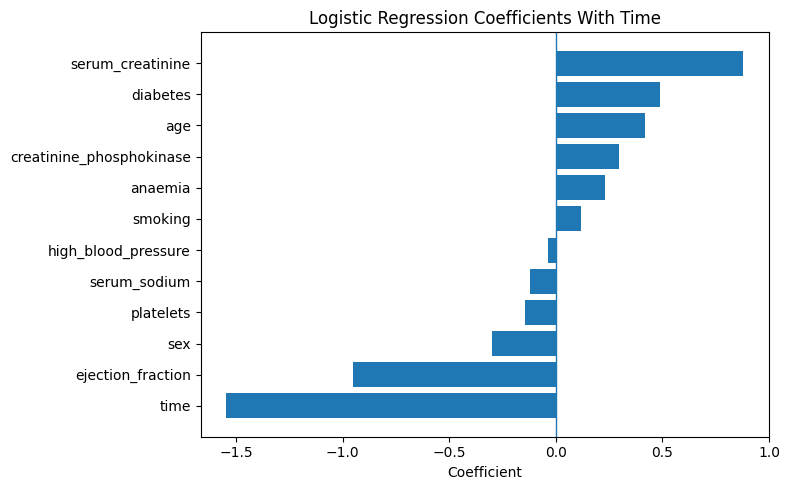

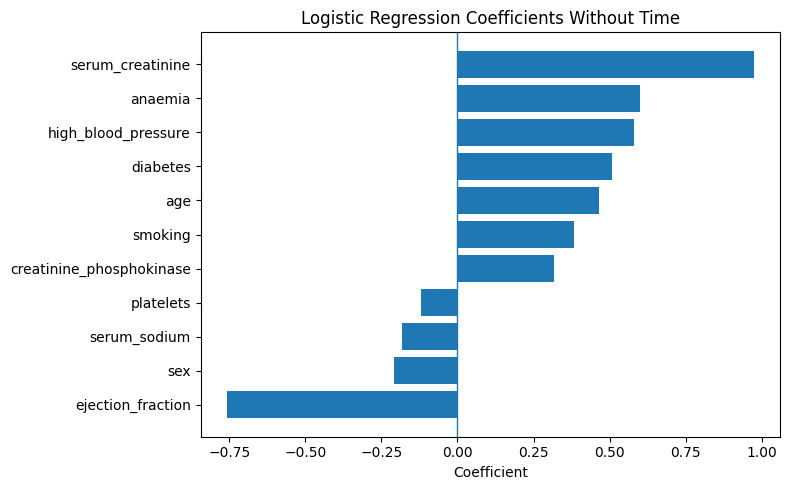

In [5]:
def plot_coefficients(table, file_name, title, top_n=12):
    plot_df = table.head(top_n).sort_values("coefficient")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(plot_df["feature"], plot_df["coefficient"])
    ax.axvline(0, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Coefficient")
    plt.tight_layout()
    plt.savefig(figures_dir / file_name, dpi=300, bbox_inches="tight")
    plt.show()

plot_coefficients(coef_with_time, "logistic_coefficients_with_time.png", "Logistic Regression Coefficients With Time")
plot_coefficients(coef_without_time, "logistic_coefficients_without_time.png", "Logistic Regression Coefficients Without Time")

In [6]:
def feature_importance(model, feature_names, model_name, time_version):
    table = pd.DataFrame({
        "model": model_name,
        "feature": feature_names,
        "importance": model.feature_importances_,
        "time_version": time_version,
    })
    return table.sort_values("importance", ascending=False).reset_index(drop=True)

rf_importance_with_time = feature_importance(random_forest_with_time, X_train_rf_with_time.columns, "Random Forest", "with_time")
rf_importance_without_time = feature_importance(random_forest_without_time, X_train_rf_without_time.columns, "Random Forest", "without_time")
tree_importance_with_time = feature_importance(decision_tree_with_time, X_train_tree_with_time.columns, "Decision Tree", "with_time")
tree_importance_without_time = feature_importance(decision_tree_without_time, X_train_tree_without_time.columns, "Decision Tree", "without_time")
gb_importance_with_time = feature_importance(gradient_boosting_with_time, X_train_gb_with_time.columns, "Gradient Boosting", "with_time")
gb_importance_without_time = feature_importance(gradient_boosting_without_time, X_train_gb_without_time.columns, "Gradient Boosting", "without_time")

importance_tables = {
    "random_forest_importance_with_time.csv": rf_importance_with_time,
    "random_forest_importance_without_time.csv": rf_importance_without_time,
    "decision_tree_importance_with_time.csv": tree_importance_with_time,
    "decision_tree_importance_without_time.csv": tree_importance_without_time,
    "gradient_boosting_importance_with_time.csv": gb_importance_with_time,
    "gradient_boosting_importance_without_time.csv": gb_importance_without_time,
}

for file_name, table in importance_tables.items():
    table.to_csv(tables_dir / file_name, index=False)

rf_importance_with_time.head(10)

,model,feature,importance,time_version
0,Random Forest,time,0.363514,with_time
1,Random Forest,serum_creatinine,0.158318,with_time
2,Random Forest,ejection_fraction,0.128968,with_time
3,Random Forest,creatinine_phosphokinase,0.078512,with_time
4,Random Forest,platelets,0.073624,with_time
5,Random Forest,age,0.066991,with_time
6,Random Forest,serum_sodium,0.063245,with_time
7,Random Forest,anaemia,0.016787,with_time
8,Random Forest,high_blood_pressure,0.013863,with_time
9,Random Forest,smoking,0.013488,with_time


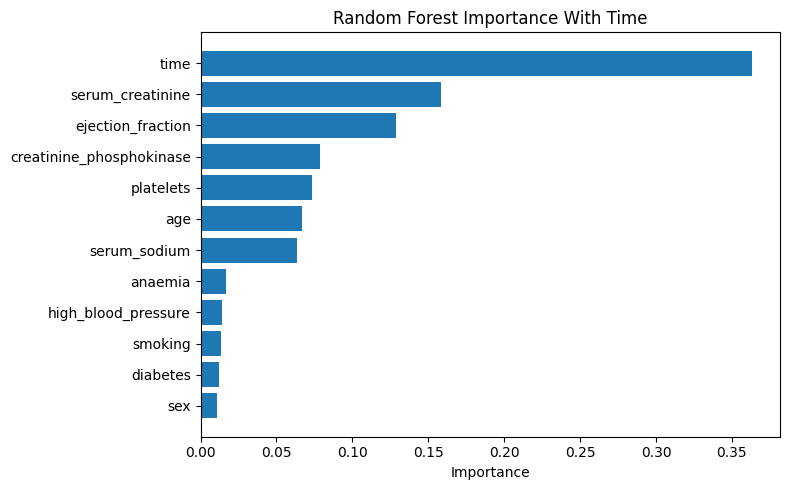

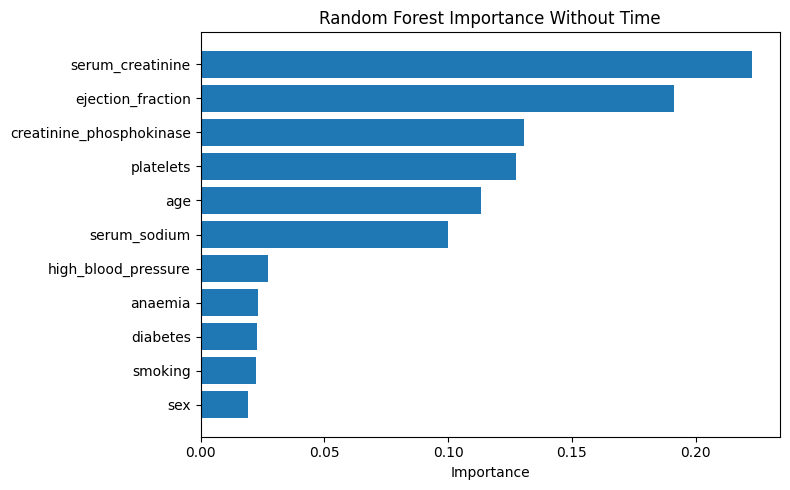

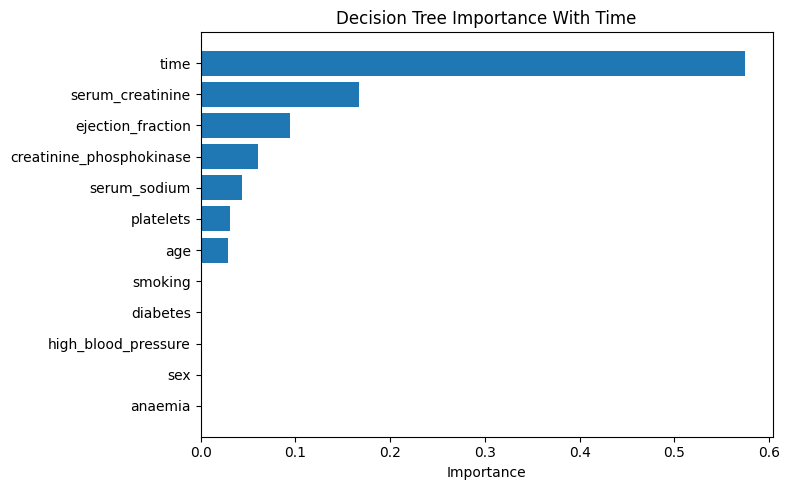

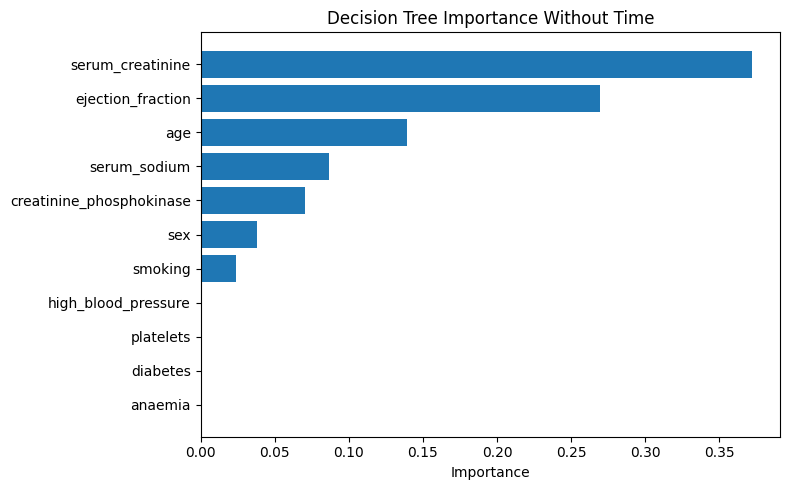

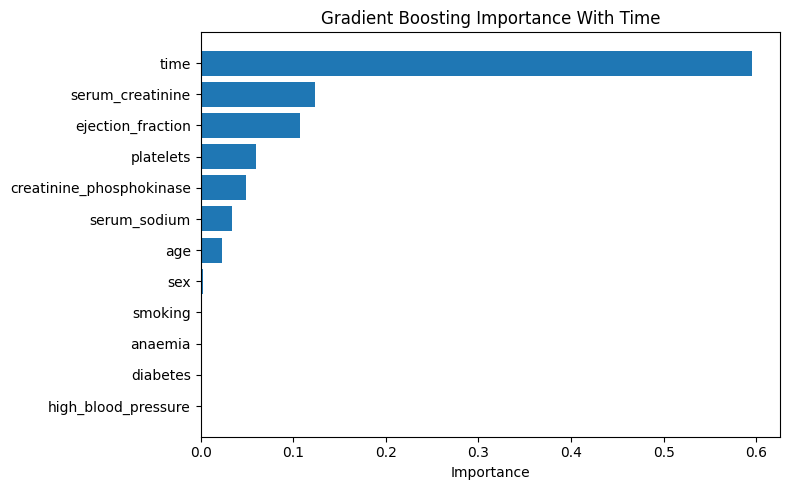

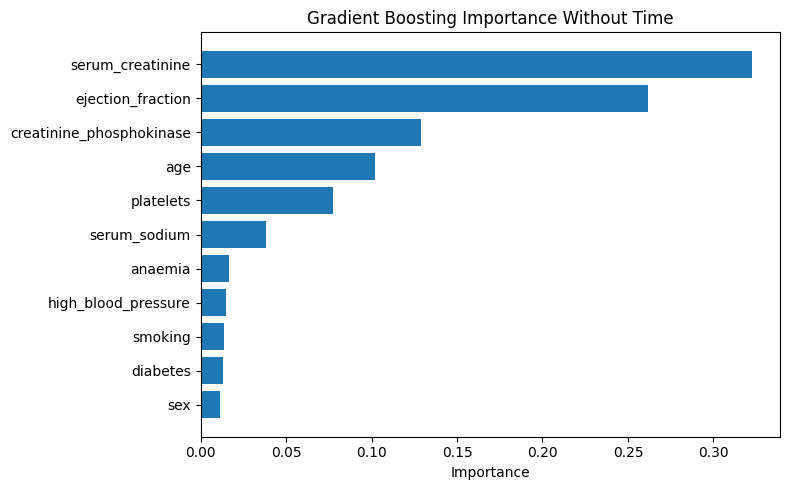

In [7]:
def plot_importance(table, file_name, title, top_n=12):
    plot_df = table.head(top_n).sort_values("importance")
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.barh(plot_df["feature"], plot_df["importance"])
    ax.set_title(title)
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.savefig(figures_dir / file_name, dpi=300, bbox_inches="tight")
    plt.show()

plot_importance(rf_importance_with_time, "random_forest_importance_with_time.png", "Random Forest Importance With Time")
plot_importance(rf_importance_without_time, "random_forest_importance_without_time.png", "Random Forest Importance Without Time")
plot_importance(tree_importance_with_time, "decision_tree_importance_with_time.png", "Decision Tree Importance With Time")
plot_importance(tree_importance_without_time, "decision_tree_importance_without_time.png", "Decision Tree Importance Without Time")
plot_importance(gb_importance_with_time, "gradient_boosting_importance_with_time.png", "Gradient Boosting Importance With Time")
plot_importance(gb_importance_without_time, "gradient_boosting_importance_without_time.png", "Gradient Boosting Importance Without Time")

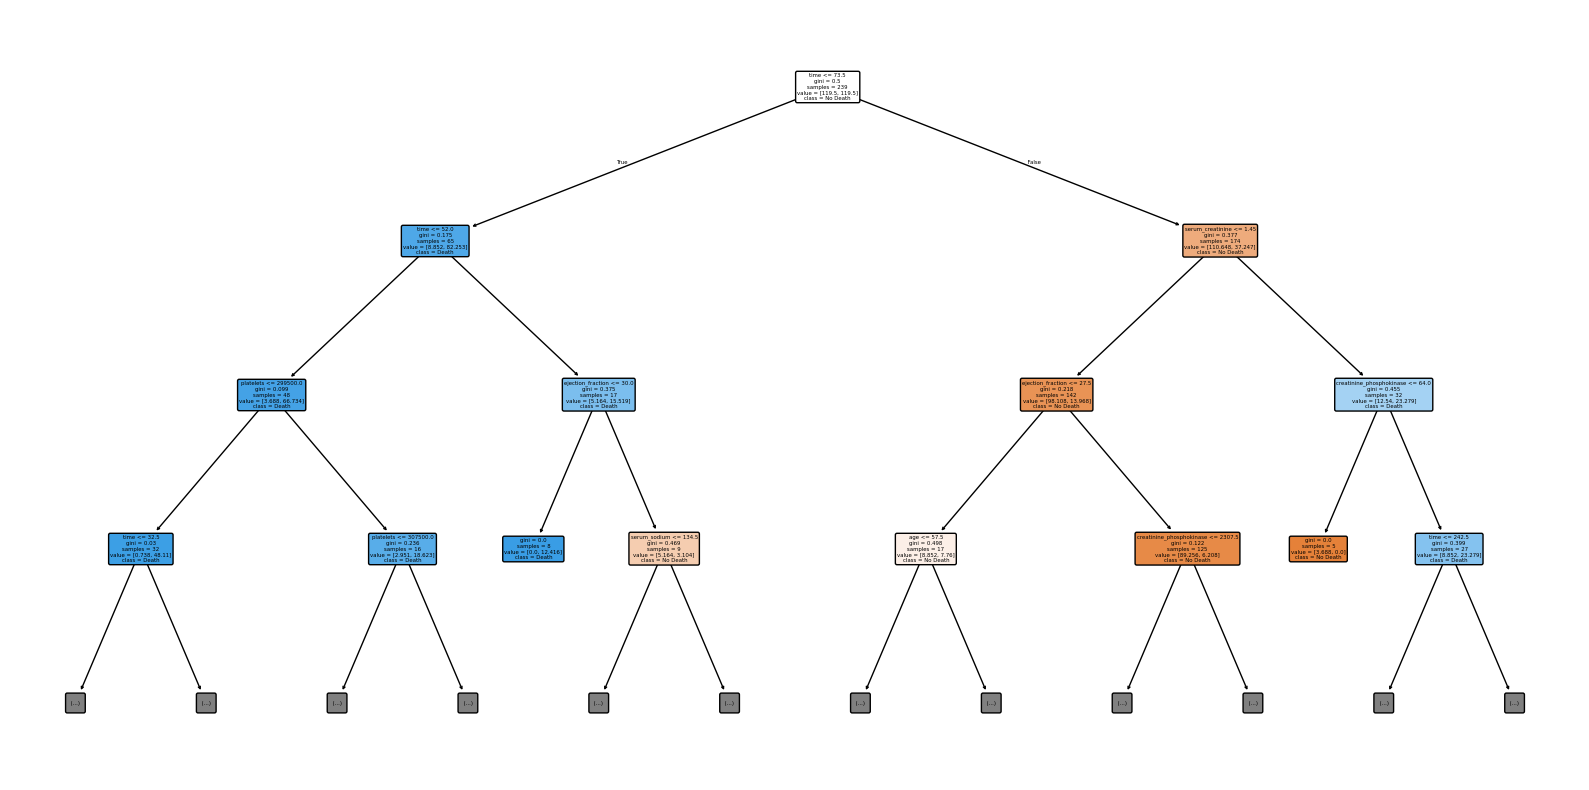

In [8]:
fig, ax = plt.subplots(figsize=(16, 8))
plot_tree(
    decision_tree_with_time,
    feature_names=X_train_tree_with_time.columns,
    class_names=["No Death", "Death"],
    filled=True,
    rounded=True,
    max_depth=3,
    ax=ax,
)
plt.tight_layout()
plt.savefig(figures_dir / "decision_tree_plot_with_time.png", dpi=300, bbox_inches="tight")
plt.show()